In [28]:
import numpy as np
from monodromy.render import _plot_coverage_set
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.circuit.library import (
    CXGate,
    RZXGate,
    UGate,
    UnitaryGate,
    XXPlusYYGate,
    iSwapGate,
    SwapGate,
)
from qiskit.circuit.random import random_circuit
from qiskit.quantum_info import Operator, average_gate_fidelity
from qiskit.quantum_info.random import random_unitary
from qiskit.transpiler import (
    InstructionProperties,
    PassManager,
    Target,
    generate_preset_pass_manager,
)
from qiskit.transpiler.passes import Optimize1qGatesDecomposition
from tqdm import tqdm
from weylchamber import c1c2c3

from gulps.gulps_decomposer import GulpsDecomposer
from gulps.synthesis_pass import GulpsDecompositionPass
from gulps.utils.invariants import GateInvariants
from gulps.utils.visualize import render_path
from monodromy.haar import expected_cost

# from gulps.synthesis_plugin import GulpsSynthesisPlugin

In [29]:
from gulps.utils.logging_config import logger

logger.setLevel("INFO")
# logger.setLevel("DEBUG")

In [30]:
gate = iSwapGate().power(1 / 2)

decomposer = GulpsDecomposer(
    gate_set=[gate],
    costs=[1.0],
    precompute_polytopes=True,
)

output_circuit = decomposer._run(gate)
fidelity = average_gate_fidelity(Operator(gate), Operator(output_circuit))

### Usage as a Decomposer

In [31]:
def fsim(theta, phi):
    _fsim = QuantumCircuit(2, name="fsim")
    _fsim.append(XXPlusYYGate(2 * theta), [0, 1])
    _fsim.cp(phi, 0, 1)
    return _fsim.to_gate()


# comment out what you don't want or add your own
isa = [
    # (CXGate(), 1.0, "cx"),
    # (CXGate().power(1 / 2), 1 / 2, "sqrt2cx"),
    (iSwapGate().power(1 / 2), 1 / 2, "sqrt2iswap"),
    (iSwapGate().power(1 / 3), 1 / 3, "sqrt3iswap"),
    # (iSwapGate().power(1 / 4), 1 / 4, "sqrt4iswap"),
    # (fsim(np.pi / 2, np.pi / 6).power(1.0), 1.0, "fsim"),
    # (fsim(np.pi / 2, np.pi / 6).power(1 / 2), 1 / 2, "sqrt2fsim"),
    # (fsim(np.pi / 2, np.pi / 6).power(1 / 3), 1 / 3, "sqrt3fsim"),
    # (SwapGate(), 0.0, "swap"),
]
gate_set, costs, names = zip(*isa)
decomposer = GulpsDecomposer(gate_set=gate_set, costs=costs, names=names)

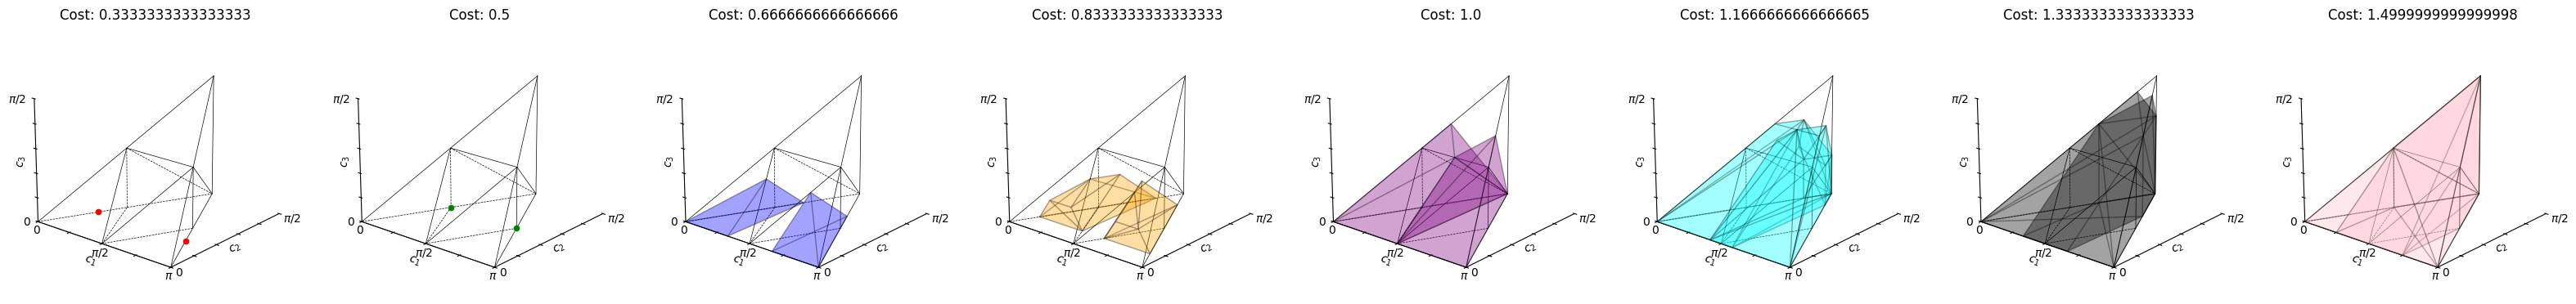

0.948418508581061


In [32]:
if hasattr(decomposer.isa, "coverage_set"):
    _plot_coverage_set(decomposer.isa.coverage_set)
    print(expected_cost(decomposer.isa.coverage_set))

In [33]:
N = 100
fidelities = []

for idx in tqdm(range(N)):
    u = random_unitary(4, seed=idx)
    v = Operator(decomposer(u))
    fid = average_gate_fidelity(u, v)
    fidelities.append(fid)

    if fid < 1 - 1e-6:
        print(f"Unitary {idx} fidelity is low: {fid:.8f}")
        print("Canonical invariants:")
        print("U:", c1c2c3(u))
        print("V:", c1c2c3(v))
        print("\n")
        continue

# Summary statistics
fidelities = np.array(fidelities)
print(f"\nSummary across {len(fidelities)} samples:")
print(f"  Median fidelity: {np.median(fidelities)}")
print(f"  Mean fidelity:   {np.mean(fidelities)}")
print(f"  Minimum fidelity:{np.min(fidelities)}")

  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [00:09<00:00, 10.56it/s]


Summary across 100 samples:
  Median fidelity: 1.0
  Mean fidelity:   0.999999999990678
  Minimum fidelity:0.999999999091966


#### Inspecting the pieces

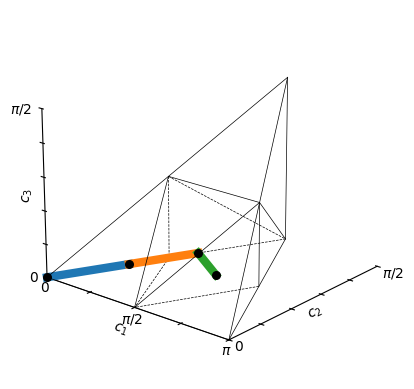

In [ ]:
example_input = random_unitary(4, seed=None)
example_sentence, example_intermediates = decomposer._best_decomposition(
    target_inv=GateInvariants.from_unitary(example_input, enforce_alcove=True)
)
render_path(example_intermediates);

In [ ]:
# NOTE, try with/out this reflection.
# the Decomposer has interal logic to handle this.
# example_intermediates = [x.rho_reflect for x in example_intermediates]

example_segment_solutions = decomposer._numerics._synthesize_segments(
    example_sentence, example_intermediates
)
print("Segment solutions:", example_segment_solutions)

Segment solutions: [array([ 1.16218336, -3.3418628 ,  6.2244062 , -5.33800476, -1.85637194,
        3.76855708]), array([-18.13980383,  -3.26743814,  11.72891608,   0.65687639,
         0.11832077,   9.13396091])]


Input unitary weyl invariants: (np.float64(0.52208207), np.float64(0.2720658), np.float64(0.02294207))
Output unitary weyl invariants: (np.float64(0.52208206), np.float64(0.27206579), np.float64(0.02294207))


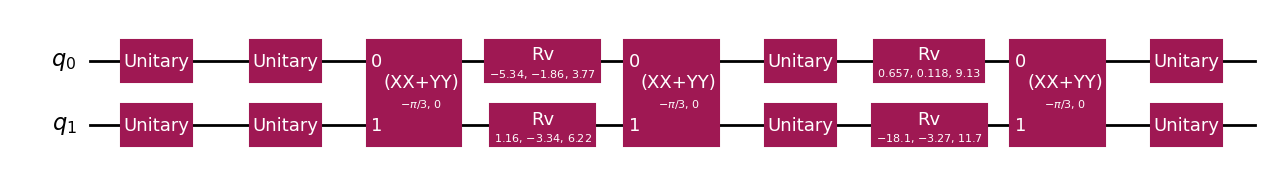

In [ ]:
# Recover unitary equivalence by promoting local equivalence
ret = decomposer._numerics._stitch_segments(
    example_sentence, example_intermediates, example_segment_solutions
)
U, V = c1c2c3(example_input), c1c2c3(Operator(ret).data)
print("Input unitary weyl invariants:", U)
print("Output unitary weyl invariants:", V)

ret.draw("mpl")

### Usage as a TransformationPass

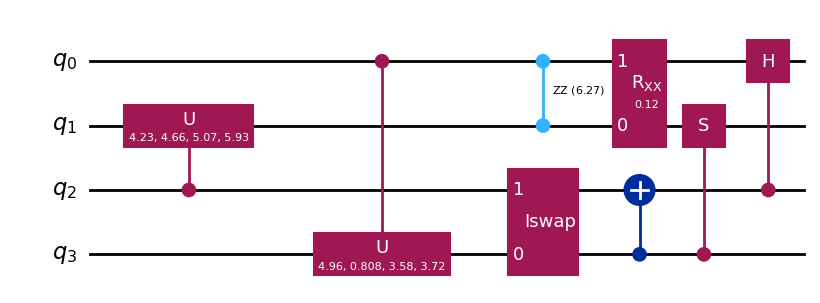

TypeError: unhashable type: 'XXPlusYYGate'

In [21]:
input_qc = random_circuit(
    4, 4, max_operands=2, num_operand_distribution={1: 0.2, 2: 0.8}
)
display(input_qc.draw("mpl"))

pm = PassManager(
    [
        GulpsDecompositionPass(gate_set, costs),
        Optimize1qGatesDecomposition(),
    ]
)
output_qc = pm.run(input_qc)
output_qc.draw("mpl", fold=-1)

### Usage as a Unitary Synthesis Plugin

In [ ]:
# check that the plugin is installed
from qiskit.transpiler.passes.synthesis import unitary_synthesis_plugin_names

unitary_synthesis_plugin_names()

['gulps', 'aqc', 'clifford', 'default', 'sk']

In [ ]:
# create some mock hetereogeneous ISA backend
target = Target()

target.add_instruction(
    RZXGate(np.pi / 2),
    {
        (0, 1): InstructionProperties(
            duration=100,
            error=0.01,
        )
    },
    name="cx",
)
target.add_instruction(
    RZXGate(np.pi / 4),
    {
        (0, 1): InstructionProperties(
            duration=50,
            error=0.05,
        )
    },
    name="scx",
)

target.add_instruction(
    XXPlusYYGate(np.pi),
    {
        (0, 1): InstructionProperties(
            duration=200,
            error=0.02,
        )
    },
    name="iswap",
)
target.add_instruction(
    XXPlusYYGate(np.pi / 2),
    {
        (0, 1): InstructionProperties(
            duration=100,
            error=0.01,
        )
    },
    name="siswap",
)

theta = Parameter("theta")
phi = Parameter("phi")
lam = Parameter("lambda")
u_props = {
    (0,): InstructionProperties(duration=0, error=0),
    (1,): InstructionProperties(duration=0, error=0),
}
target.add_instruction(UGate(theta, phi, lam), u_props)

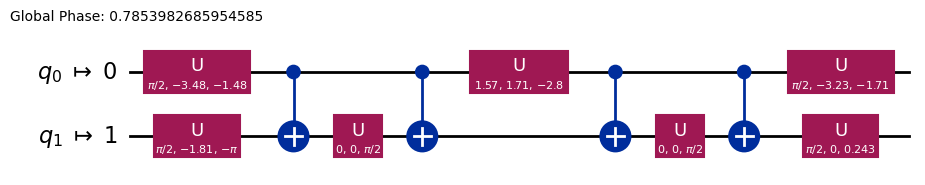

In [ ]:
circuit = QuantumCircuit(2)
# circuit.cx(0, 1)
circuit.append(UnitaryGate(Operator(CXGate())), [0, 1])

pass_manager = generate_preset_pass_manager(
    optimization_level=3,
    target=target,
    translation_method="synthesis",
    unitary_synthesis_method="gulps",
)

out = pass_manager.run(circuit)
out.draw("mpl")